In [8]:
import cga_utils
import prompt_versions
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
from langchain.globals import set_llm_cache
from langchain_community.cache import SQLiteCache
set_llm_cache(SQLiteCache(database_path=".langchain.ollama41.db"))


In [21]:
from langchain_community.chat_models import ChatOllama
llm = ChatOllama(model="deepseek-r1:7b", temperature = 0.0, top_p = 1, repeat_penalty=1, presence_penalty=0, frequency_penalty=0)  # vagy bármely más elérhető Ollama modell

In [ ]:
import pandas as pd
import os
messages = prompt_versions.prompt_versions['V18']
messages = [(a, t.replace('/nothink','')) for (a,t)  in messages]
messages[-1] = ( messages[-1][0],  messages[-1][1] + "/nothink" ) 



#problematic_qids = list(pd.read_csv('res/e37.csv').query('error_code == "selection_error" and calc_pattern == "(#+#)/#"')['qid'])
#df = pd.read_csv('res/e38_19.csv')
#problematic_qids = list(df[df["question"].str.contains("percentage change")]['qid'])
os.environ["CGA_TRACE_RESP"] = 'True'
res = cga_utils.execute_datset_predictions(llm, messages)
#res = cga_utils.execute_datset_predictions(llm, messages, ['b2786c1a-37de-4120-b03c-32bf5c81f157'])
#res = []
#for i in range(3):
#    set_llm_cache(SQLiteCache(database_path=".langchain.ollama38_run" + str(i) + ".db"))
#    res.append(cga_utils.execute_datset_predictions(llm, messages))

0it [00:00, ?it/s]

b2786c1a-37de-4120-b03c-32bf5c81f157
What was the change in the amount for Appliances in 2019 from 2018?R:  <think>
Okay, I need to write a Python function called run that takes a value_list and a question. The question here is about the change in the amount for Appliances in 2019 from 2018. So, I need to find the numbers for Appliances in both years and calculate the difference.

First, I'll look through the value_list to find the entries for 'Appliances'. Each entry has a 'category' and 'header1' which is the solution name. So, I'm looking for where category is 'Appliances' and header1 is 'Communications Solutions:'? Wait, no, the header1 for Appliances would be 'Appliances', right? Wait, looking at the data, the header1 for Appliances is 'Communications Solutions:' in the entries. Wait, no, in the data provided, the header1 for Appliances is 'Communications Solutions:' but the category is 'Appliances'. Wait, no, looking at the data, the entries for 'Appliances' have header1 as 'Comm

In [12]:
annotated_results = cga_utils.annotate_results(res)
#annotated_results.to_csv('res/Ollama_2_gemma3n_e4b_code_values_v11_m1.csv')
cga_utils.calc_overall_value_match(annotated_results)

1.0

In [13]:
annotated_results

,qid,question,derivation,calc_pattern,pred,pred_scale,answer,scale,value_match,selection_success,...,is_parenth_in_table,has_code_abs,error_text,value_list,code,selected_values,needed_values,exact_match,error_code,aggr_calc_pattern
0,b2786c1a-37de-4120-b03c-32bf5c81f157,What was the change in the amount for Applianc...,680-774,#-#,-94.0,million,-94,million,True,False,...,False,False,,"[{'number_value': 5686.0, 'scale': 'million', ...",def run(value_list):\n # Find the 2019 Appl...,"[-94.0, -94.0]","[680.0, 774.0]",True,none,other


In [8]:

cga_utils.calc_overall_em(annotated_results), cga_utils.calc_overall_em_alt(annotated_results)

(0.38193018480492813, 0.38193018480492813)

In [9]:
annotated_results.to_csv('res/e40_18.csv')

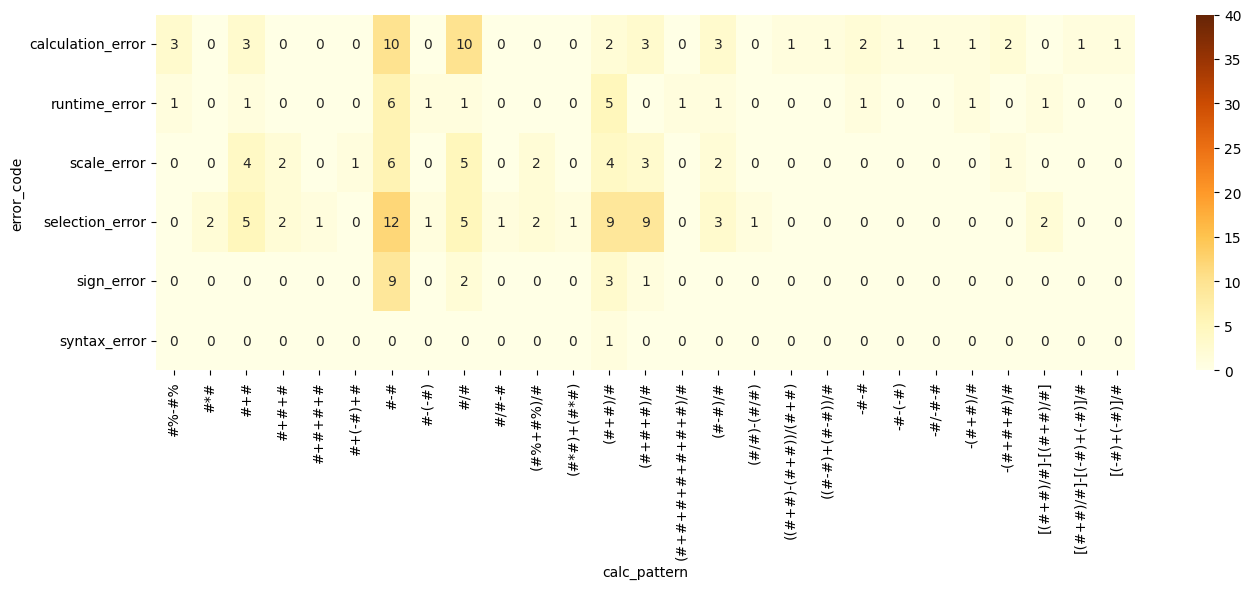

167

In [31]:
df = ars[0].query('error_code != "none"')
cga_utils.crosstab_heatmap(df, 'error_code', 'calc_pattern', 40)
len(df)